In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("combined_product_sales_predictive_data.csv")

df.head()

,Product Name,ID,Sales,Quantity,Price,City,Customer,Date
0,Furniture - Bookcases,B-25601,1275.0,7,182.14,Ahmedabad,Bharat,01-04-2018
1,Clothing - Stole,B-25601,66.0,5,13.20,Ahmedabad,Bharat,01-04-2018
2,Clothing - Hankerchief,B-25601,8.0,3,2.67,Ahmedabad,Bharat,01-04-2018
3,Electronics - Electronic Games,B-25601,80.0,4,20.00,Ahmedabad,Bharat,01-04-2018
4,Electronics - Phones,B-25602,168.0,2,84.00,Pune,Pearl,01-04-2018


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape: (1500, 8)

Columns:
Index(['Product Name', 'ID', 'Sales', 'Quantity', 'Price', 'City', 'Customer',
       'Date'],
      dtype='object')

Data Types:
Product Name     object
ID               object
Sales           float64
Quantity          int64
Price           float64
City             object
Customer         object
Date             object
dtype: object

Missing Values:
Product Name    0
ID              0
Sales           0
Quantity        0
Price           0
City            0
Customer        0
Date            0
dtype: int64

Duplicate Rows:
0


In [4]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [5]:
df['Date'].head()

0   2018-04-01
1   2018-04-01
2   2018-04-01
3   2018-04-01
4   2018-04-01
Name: Date, dtype: datetime64[ns]

In [6]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1500, 8)


In [7]:
print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())
print("Number of unique dates:", df['Date'].nunique())

Start Date: 2018-04-01 00:00:00
End Date: 2019-03-31 00:00:00
Number of unique dates: 307


In [8]:
df[['Sales', 'Quantity', 'Price']].describe()

,Sales,Quantity,Price
count,1500.000000,1500.000000,1500.000000
mean,287.668000,3.743333,78.435387
std,461.050488,2.184942,106.822764
min,4.000000,1.000000,2.330000
25%,45.000000,2.000000,15.000000
50%,118.000000,3.000000,37.000000
75%,322.000000,5.000000,105.000000
max,5729.000000,14.000000,872.600000


In [9]:
total_sales = df['Sales'].sum()

print("Total Sales:", total_sales)

Total Sales: 431502.0


In [10]:
total_quantity = df['Quantity'].sum()

print("Total Quantity:", total_quantity)

Total Quantity: 5615


In [11]:
average_price = df['Price'].mean()

print("Average Price:", average_price)

Average Price: 78.43538666666667


In [12]:
product_sales = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
)

product_sales.head(10)

Product Name
Electronics - Printers            58252.0
Furniture - Bookcases             56861.0
Clothing - Saree                  53511.0
Electronics - Phones              46119.0
Electronics - Electronic Games    39168.0
Furniture - Chairs                34222.0
Clothing - Trousers               30039.0
Furniture - Tables                22614.0
Electronics - Accessories         21728.0
Clothing - Stole                  18546.0
Name: Sales, dtype: float64

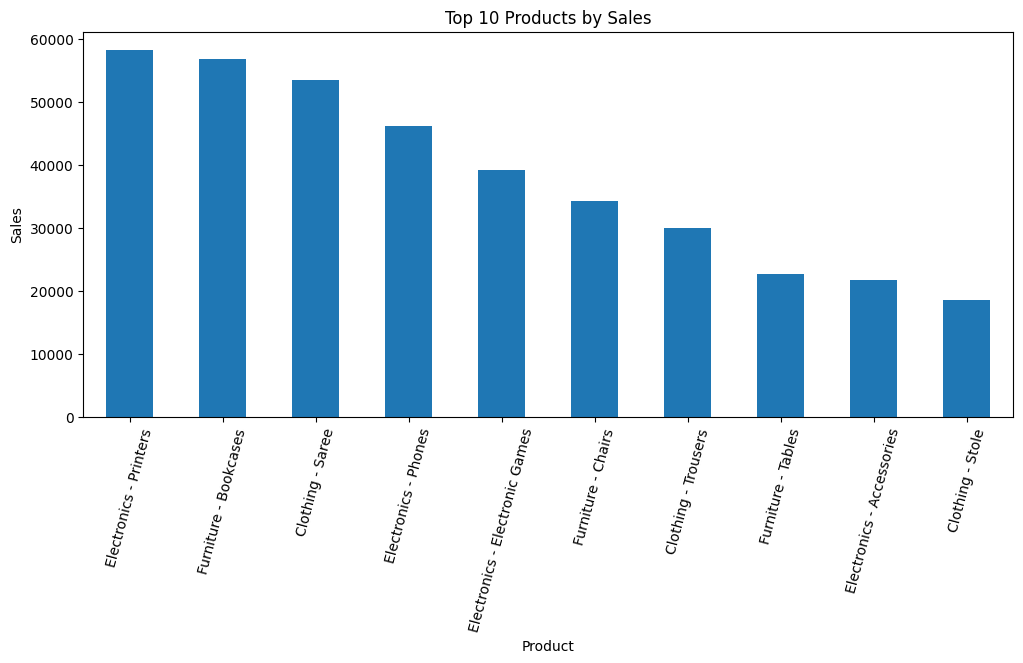

In [13]:
product_sales.head(10).plot(
    kind='bar',
    figsize=(12,5)
)

plt.title('Top 10 Products by Sales')
plt.xlabel('Product')
plt.ylabel('Sales')
plt.xticks(rotation=75)

plt.show()

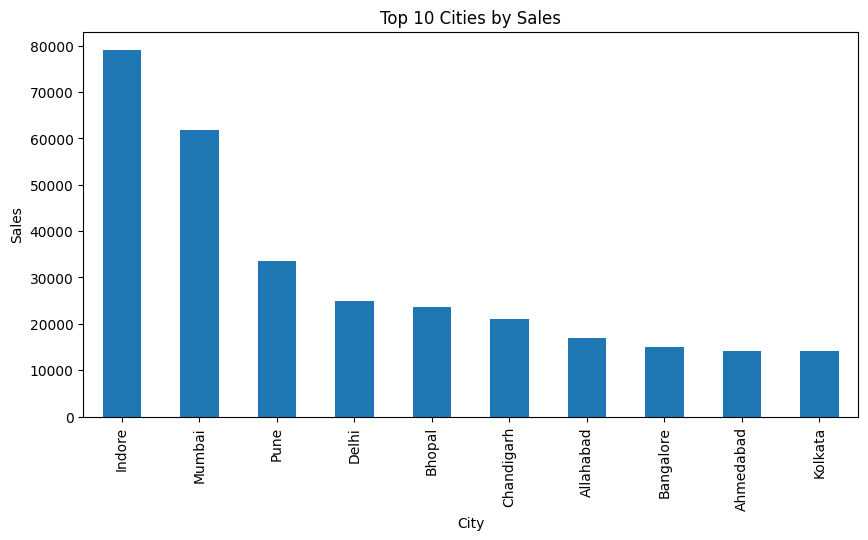

In [14]:
city_sales = (
    df.groupby('City')['Sales']
      .sum()
      .sort_values(ascending=False)
)

city_sales.head(10)

city_sales.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Cities by Sales')
plt.xlabel('City')
plt.ylabel('Sales')

plt.show()

In [15]:
monthly_sales = (
    df.set_index('Date')
      .resample('ME')['Sales']
      .sum()
      .reset_index()
)
monthly_sales.head()

,Date,Sales
0,2018-04-30,32726.0
1,2018-05-31,28545.0
2,2018-06-30,23658.0
3,2018-07-31,12966.0
4,2018-08-31,30899.0


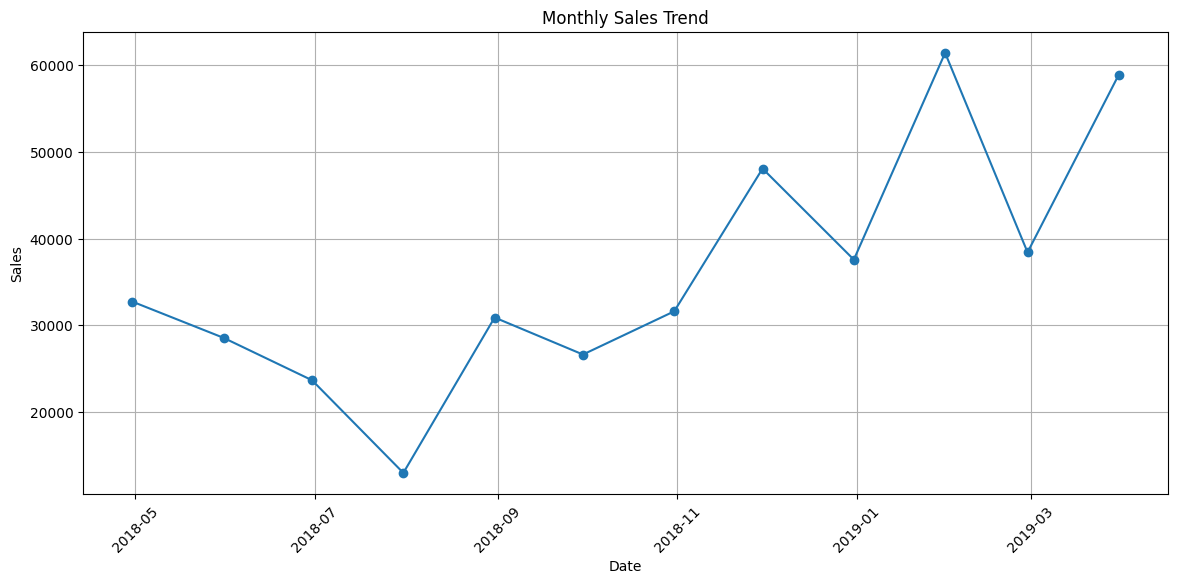

In [16]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales['Date'],
    monthly_sales['Sales'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [17]:
monthly_sales['Year'] = monthly_sales['Date'].dt.year
monthly_sales['Month'] = monthly_sales['Date'].dt.month
monthly_sales['Quarter'] = monthly_sales['Date'].dt.quarter

In [18]:
monthly_sales['Time_Index'] = np.arange(len(monthly_sales))
monthly_sales.head()

,Date,Sales,Year,Month,Quarter,Time_Index
0,2018-04-30,32726.0,2018,4,2,0
1,2018-05-31,28545.0,2018,5,2,1
2,2018-06-30,23658.0,2018,6,2,2
3,2018-07-31,12966.0,2018,7,3,3
4,2018-08-31,30899.0,2018,8,3,4


In [19]:
split_index = int(len(monthly_sales) * 0.8)

train = monthly_sales.iloc[:split_index]
test = monthly_sales.iloc[split_index:]

print("Training records:", len(train))
print("Testing records:", len(test))

Training records: 9
Testing records: 3


In [20]:
X_train = train[['Time_Index']]
y_train = train['Sales']

X_test = test[['Time_Index']]
y_test = test['Sales']

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [21]:
lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("-----------------------")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R²  :", lr_r2)

Linear Regression
-----------------------
MAE : 13630.225925925923
RMSE: 15886.611109158612
R²  : -1.3741825231053304


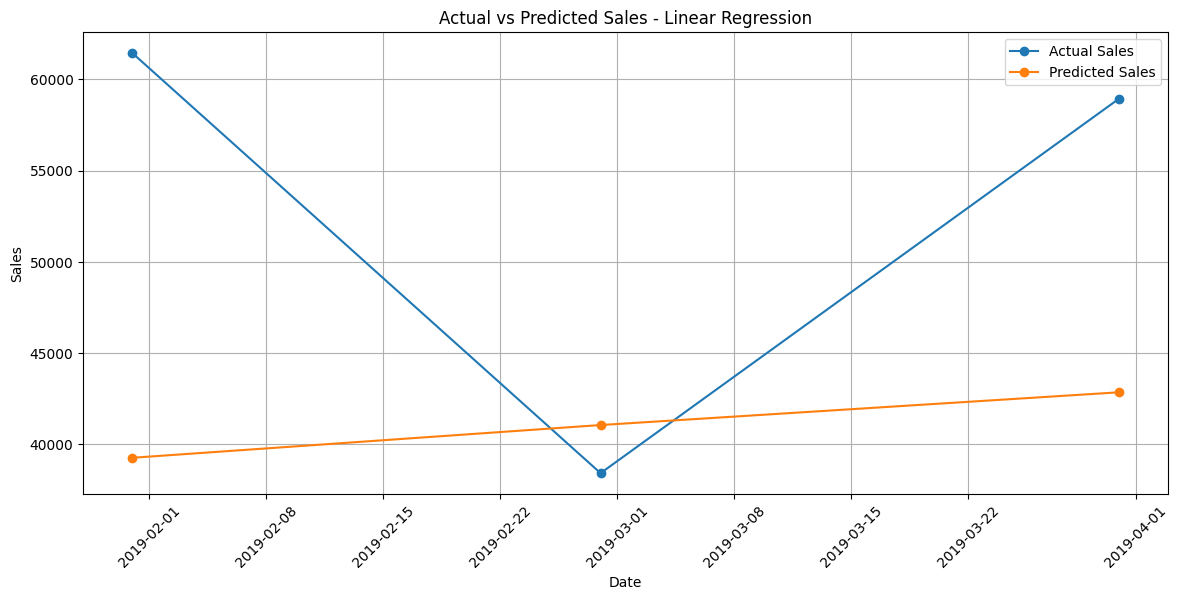

In [22]:
plt.figure(figsize=(14,6))

plt.plot(
    test['Date'],
    y_test,
    marker='o',
    label='Actual Sales'
)

plt.plot(
    test['Date'],
    lr_pred,
    marker='o',
    label='Predicted Sales'
)

plt.title('Actual vs Predicted Sales - Linear Regression')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [23]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("-----------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)


Random Forest
-----------------------
MAE : 14319.023333333333
RMSE: 17337.323852647118
R²  : -1.8275851883077041


In [24]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest'
    ],
    'MAE': [
        lr_mae,
        rf_mae
    ],
    'RMSE': [
        lr_rmse,
        rf_rmse
    ],
    'R2 Score': [
        lr_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,13630.225926,15886.611109,-1.374183
1,Random Forest,14319.023333,17337.323853,-1.827585


In [25]:
future_periods = 6

future_index = np.arange(
    len(monthly_sales),
    len(monthly_sales) + future_periods
)

future_dates = pd.date_range(
    start=monthly_sales['Date'].max() + pd.offsets.MonthEnd(1),
    periods=future_periods,
    freq='ME'
)

In [26]:
future_df = pd.DataFrame({
    'Date': future_dates,
    'Time_Index': future_index
})

future_df['Predicted_Sales'] = lr_model.predict(
    future_df[['Time_Index']]
)

future_df

,Date,Time_Index,Predicted_Sales
0,2019-04-30,12,44648.355556
1,2019-05-31,13,46441.872222
2,2019-06-30,14,48235.388889
3,2019-07-31,15,50028.905556
4,2019-08-31,16,51822.422222
5,2019-09-30,17,53615.938889


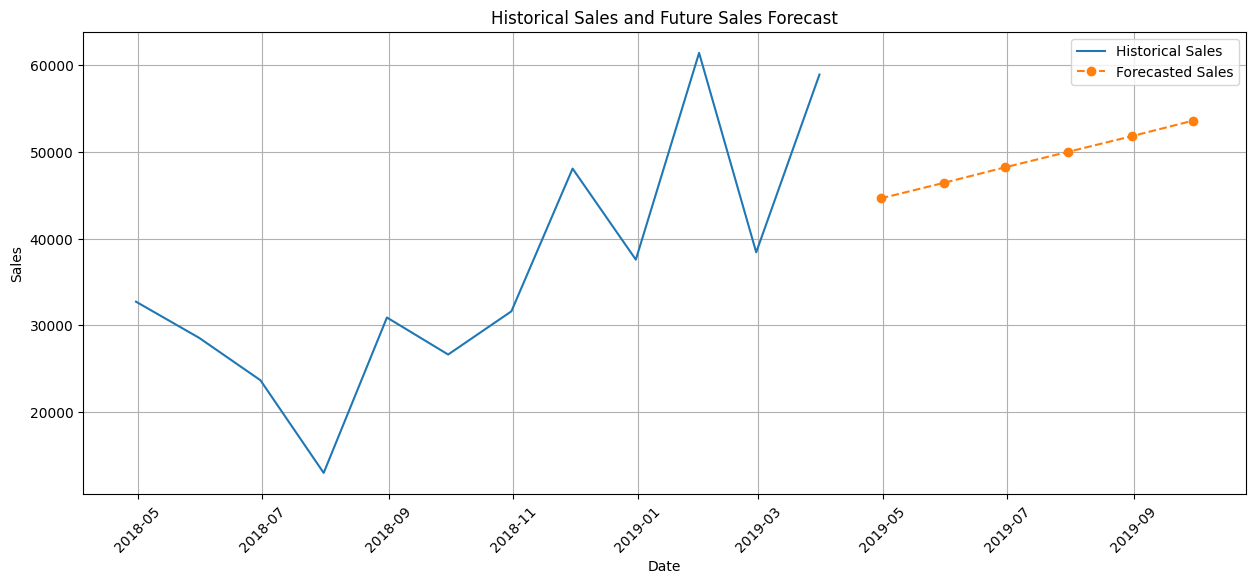

In [27]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales['Date'],
    monthly_sales['Sales'],
    label='Historical Sales'
)

plt.plot(
    future_df['Date'],
    future_df['Predicted_Sales'],
    marker='o',
    linestyle='--',
    label='Forecasted Sales'
)

plt.title('Historical Sales and Future Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()